In [87]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA

In [88]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [89]:
path = '/content/drive/MyDrive/Project_Machine_Learning/Praktikum_Mandiri_12/Data/'

df = pd.read_csv(path + 'survey lung cancer.csv')
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [91]:
df.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


In [92]:
df.duplicated().sum()

np.int64(33)

In [93]:
df[df.duplicated(keep=False)]

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
7,F,51,2,2,2,2,1,2,2,1,1,1,2,2,1,YES
13,M,58,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
23,M,60,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
51,M,63,2,2,2,1,2,2,2,2,1,1,2,1,1,YES
75,M,58,2,1,1,1,1,1,2,2,2,2,1,1,1,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES


In [94]:
df = df[df.duplicated() == False]

In [95]:
df.duplicated().sum()

np.int64(0)

In [96]:
df.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000
mean,62.909420,1.543478,1.576087,1.496377,1.507246,1.521739,1.663043,1.547101,1.547101,1.550725,1.576087,1.630435,1.467391,1.557971
std,8.379355,0.499011,0.495075,0.500895,0.500856,0.500435,0.473529,0.498681,0.498681,0.498324,0.495075,0.483564,0.499842,0.497530
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.750000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.500000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [97]:
# Distribusi kelas target
print("Nama Kelas:", df['LUNG_CANCER'].unique())
df['LUNG_CANCER'].value_counts()

Nama Kelas: ['YES' 'NO']


,count
LUNG_CANCER,
YES,238
NO,38


In [98]:
# Fitur dan label
# X = wine.data     # bisa juga df[wine.feature_names].values
# y = wine.target   # df['target'].values

# Menggunakan DataFrame 'df' yang sudah dimuat
# Mengubah kolom 'GENDER' dan 'LUNG_CANCER' menjadi numerik (Label Encoding)
df_encoded = df.copy()
df_encoded['GENDER'] = df_encoded['GENDER'].map({'M': 0, 'F': 1})
df_encoded['LUNG_CANCER'] = df_encoded['LUNG_CANCER'].map({'NO': 0, 'YES': 1})

X = df_encoded.drop('LUNG_CANCER', axis=1) # Menjadikan semua kolom kecuali 'LUNG_CANCER' sebagai fitur
y = df_encoded['LUNG_CANCER']            # Menjadikan 'LUNG_CANCER' sebagai label

print("Shape X:", X.shape)
print("Shape Y:", y.shape)

Shape X: (276, 15)
Shape Y: (276,)


In [99]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

Shape X_train: (220, 15)
Shape X_test: (56, 15)


In [100]:
# Standarisasi (mean=0, std=1)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) # fit + transform pada data train
X_test_scaled = scaler.transform(X_test) # hanya transform pada data test

X_train_scaled[:5]

array([[ 1.05611771,  0.83101961, -1.12607337,  0.81649658, -0.98198051,
         1.03704952,  0.94686415,  0.71919495,  0.92973479, -1.06579657,
         0.92973479,  0.83989663, -1.39044357, -0.93826536, -1.14707867],
       [ 1.05611771,  1.3336294 ,  0.8880416 ,  0.81649658,  1.01835015,
         1.03704952, -1.05611771,  0.71919495, -1.07557554,  0.93826536,
        -1.07557554,  0.83989663,  0.71919495,  1.06579657, -1.14707867],
       [ 1.05611771, -0.29985244, -1.12607337, -1.22474487, -0.98198051,
        -0.96427411,  0.94686415,  0.71919495, -1.07557554, -1.06579657,
        -1.07557554, -1.1906227 ,  0.71919495, -0.93826536, -1.14707867],
       [ 1.05611771, -0.29985244,  0.8880416 ,  0.81649658,  1.01835015,
         1.03704952, -1.05611771,  0.71919495,  0.92973479, -1.06579657,
        -1.07557554, -1.1906227 ,  0.71919495,  1.06579657,  0.87177979],
       [ 1.05611771,  0.20275736,  0.8880416 ,  0.81649658,  1.01835015,
         1.03704952, -1.05611771,  0.71919495, 

In [101]:
# Model SVM tanpa PCA
svm_no_pca = SVC(kernel='linear', gamma = "scale",random_state=42)
svm_no_pca.fit(X_train_scaled, y_train)

# Prediksi dan evaluasi
y_pred_no_pca = svm_no_pca.predict(X_test_scaled)

acc_no_pca = accuracy_score(y_test, y_pred_no_pca)
print("Akurasi tanpa PCA:", acc_no_pca)

print("\nClassification Report (tanpa PCA):")
print(classification_report(y_test, y_pred_no_pca, target_names=['NO', 'YES']))

Akurasi tanpa PCA: 0.9285714285714286

Classification Report (tanpa PCA):
              precision    recall  f1-score   support

          NO       0.70      0.88      0.78         8
         YES       0.98      0.94      0.96        48

    accuracy                           0.93        56
   macro avg       0.84      0.91      0.87        56
weighted avg       0.94      0.93      0.93        56



In [102]:
from sklearn.decomposition import PCA

# PCA dengan 3 komponen utama
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape X_train_pca:", X_train_pca.shape) # (n_train, 3)
print("Shape X_test_pca:", X_test_pca.shape) # (n_test, 3)

Shape X_train_pca: (220, 3)
Shape X_test_pca: (56, 3)


In [103]:
# Variansi yang dijelaskan oleh tiap komponen
explained_var = pca.explained_variance_ratio_
print("Variansi yang dijelaskan oleh tiap komponen:", explained_var)
print("Total variansi yang dijelaskan 3 komponen pertama:", explained_var.sum())

Variansi yang dijelaskan oleh tiap komponen: [0.18432018 0.14237989 0.10404248]
Total variansi yang dijelaskan 3 komponen pertama: 0.4307425578435464


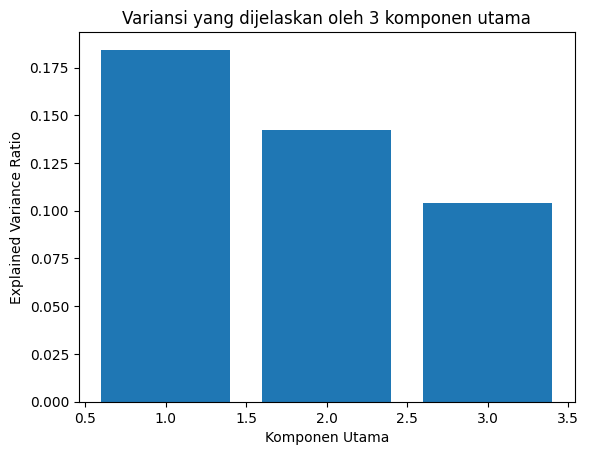

In [105]:
plt.bar([1,2,3], explained_var)
plt.xlabel("Komponen Utama")
plt.ylabel("Explained Variance Ratio")
plt.title("Variansi yang dijelaskan oleh 3 komponen utama")
plt.show()

In [107]:
# Model SVM dengan PCA
svm_pca = SVC(kernel = 'rbf', gamma = "scale", random_state=42)
svm_pca.fit(X_train_pca, y_train)

# Prediksi dan evaluasi
y_pred_pca = svm_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, y_pred_pca)
print("Akurasi SVM dengan PCA (3 Komponen):", acc_pca)

print("\nClassification Report (dengan PCA):")
print(classification_report(y_test, y_pred_pca, target_names=['NO', 'YES']))

Akurasi SVM dengan PCA (3 Komponen): 0.875

Classification Report (dengan PCA):
              precision    recall  f1-score   support

          NO       1.00      0.12      0.22         8
         YES       0.87      1.00      0.93        48

    accuracy                           0.88        56
   macro avg       0.94      0.56      0.58        56
weighted avg       0.89      0.88      0.83        56



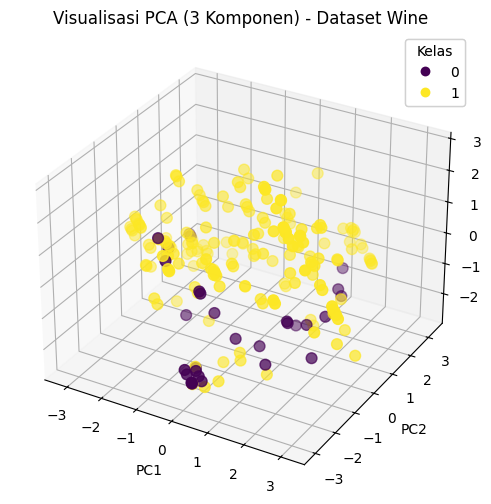

In [108]:
# Visualisasi 3D PCA (menggunakan data train)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
X_train_pca[:, 0],
X_train_pca[:, 1],
X_train_pca[:, 2],
c=y_train,
s=60
)

ax.set_title('Visualisasi PCA (3 Komponen) - Dataset Wine')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

# Tambahkan legend berdasarkan kelas
legend1 = ax.legend(
*scatter.legend_elements(),
title="Kelas"
)
ax.add_artist(legend1)

plt.show()